In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk

In [8]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\soura\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\soura\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\soura\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\soura\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [10]:
df = pd.read_csv("twitter_dataset.csv")

In [11]:
df.head()

,Tweet_ID,Username,Text,Retweets,Likes,Timestamp
0,1,julie81,Party least receive say or single. Prevent pre...,2,25,2023-01-30 11:00:51
1,2,richardhester,Hotel still Congress may member staff. Media d...,35,29,2023-01-02 22:45:58
2,3,williamsjoseph,Nice be her debate industry that year. Film wh...,51,25,2023-01-18 11:25:19
3,4,danielsmary,Laugh explain situation career occur serious. ...,37,18,2023-04-10 22:06:29
4,5,carlwarren,Involve sense former often approach government...,27,80,2023-01-24 07:12:21


In [12]:
df.shape

(10000, 6)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   10000 non-null  int64 
 1   Username   10000 non-null  object
 2   Text       10000 non-null  object
 3   Retweets   10000 non-null  int64 
 4   Likes      10000 non-null  int64 
 5   Timestamp  10000 non-null  object
dtypes: int64(3), object(3)
memory usage: 468.9+ KB


In [14]:
tweets = df[['Text']].copy()
tweets.head()

,Text
0,Party least receive say or single. Prevent pre...
1,Hotel still Congress may member staff. Media d...
2,Nice be her debate industry that year. Film wh...
3,Laugh explain situation career occur serious. ...
4,Involve sense former often approach government...


In [15]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [16]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = text.split()

    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)

In [17]:
tweets["clean_text"] = tweets["Text"].apply(clean_text)

In [18]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

In [86]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def predict_sentiment(text):
    score = sia.polarity_scores(text)
    compound = score['compound']

    print(score)   # temporary debugging

    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [87]:
tweets["Sentiment"] = tweets["clean_text"].apply(get_sentiment)

In [88]:
tweets.head()

,Text,clean_text,Sentiment
0,Party least receive say or single. Prevent pre...,party least receive say single prevent prevent...,Positive
1,Hotel still Congress may member staff. Media d...,hotel still congress may member staff medium d...,Positive
2,Nice be her debate industry that year. Film wh...,nice debate industry year film generation push...,Positive
3,Laugh explain situation career occur serious. ...,laugh explain situation career occur serious f...,Positive
4,Involve sense former often approach government...,involve sense former often approach government...,Positive


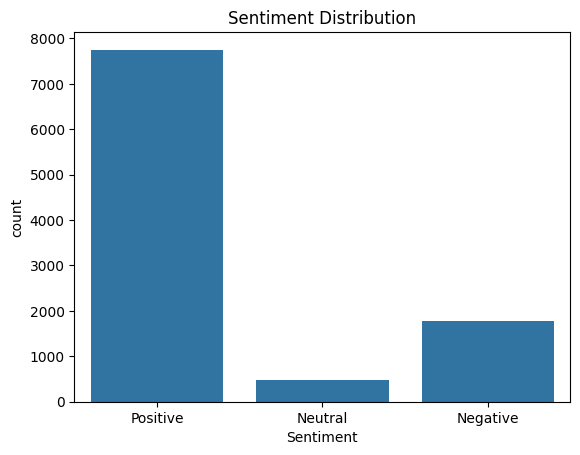

In [89]:
sns.countplot(x="Sentiment", data=tweets)

plt.title("Sentiment Distribution")

plt.show()

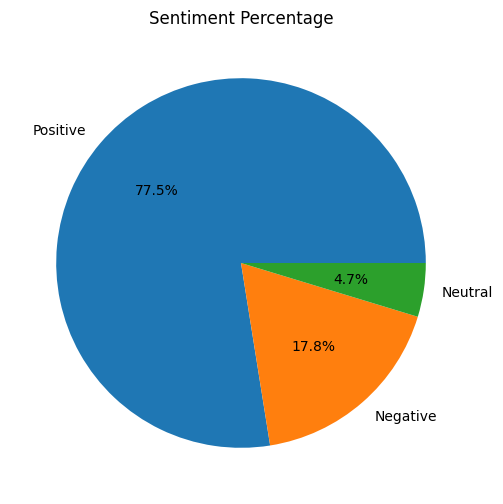

In [90]:
tweets["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")

plt.title("Sentiment Percentage")

plt.show()

In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [92]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(tweets["clean_text"])

y = tweets["Sentiment"]

In [93]:
from sklearn.model_selection import train_test_split

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [95]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [96]:
y_pred = model.predict(X_test)

In [97]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8435

In [98]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.94      0.43      0.59       377
     Neutral       0.00      0.00      0.00        93
    Positive       0.83      1.00      0.91      1530

    accuracy                           0.84      2000
   macro avg       0.59      0.48      0.50      2000
weighted avg       0.82      0.84      0.81      2000



C:\Users\soura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\soura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\soura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [99]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.94      0.43      0.59       377
     Neutral       0.00      0.00      0.00        93
    Positive       0.83      1.00      0.91      1530

    accuracy                           0.84      2000
   macro avg       0.59      0.48      0.50      2000
weighted avg       0.82      0.84      0.81      2000



C:\Users\soura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\soura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\soura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


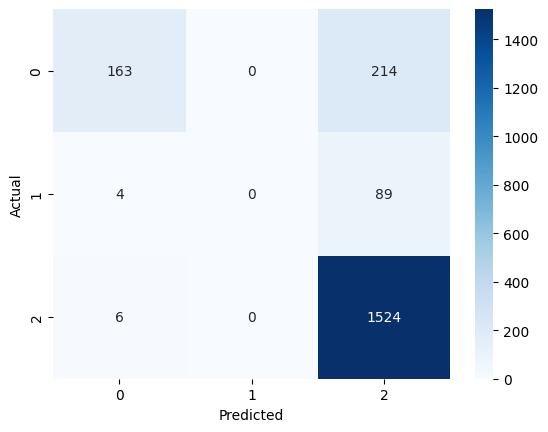

In [100]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [101]:
def predict_sentiment(text):

    cleaned = clean_text(text)

    vector = tfidf.transform([cleaned])

    prediction = model.predict(vector)

    return prediction[0]

In [102]:
predict_sentiment("I love this phone. Amazing battery life!")

'Positive'

In [103]:
predict_sentiment("Worst service ever.")

'Positive'

In [104]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

sia.polarity_scores("Worst service ever.")

{'neg': 0.672, 'neu': 0.328, 'pos': 0.0, 'compound': -0.6249}

In [105]:
print(predict_sentiment("I love this product"))
print(predict_sentiment("Worst service ever"))
print(predict_sentiment("This is amazing"))
print(predict_sentiment("I hate this"))

Positive
Positive
Positive
Positive


In [108]:
print(sia.polarity_scores("I hate this"))

{'neg': 0.787, 'neu': 0.213, 'pos': 0.0, 'compound': -0.5719}


In [109]:
print(predict_sentiment("I hate this"))

Positive
